<a href="https://colab.research.google.com/github/sjdyeet/concept_of_ai/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 3.2 Regression Task




In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42


pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 120)


In [4]:
DATA_PATH = "/content/drive/MyDrive/social_media_vs_productivity.csv"
SHEET_NAME = "social_media_vs_productivity"
TARGET = "actual_productivity_score"

print("File exists:", DATA_PATH)


File exists: /content/drive/MyDrive/social_media_vs_productivity.csv


In [5]:
df = pd.read_csv(DATA_PATH, na_values=['', ' '])

# Explicit categorical columns (force consistent dtype)
cat_text_cols = ['gender', 'job_type', 'social_platform_preference']
for c in cat_text_cols:
    if c in df.columns:
        df[c] = df[c].astype('object')

# Convert boolean-like columns to pandas nullable boolean
bool_cols = ['uses_focus_apps', 'has_digital_wellbeing_enabled']
for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].map({'True': True, 'False': False, True: True, False: False}).astype('boolean')

# Ensure numeric columns are numeric (coerce errors to NaN)
num_candidate_cols = [
    'age',
    'daily_social_media_time',
    'number_of_notifications',
    'work_hours_per_day',
    'perceived_productivity_score',
    'actual_productivity_score',
    'stress_level',
    'sleep_hours',
    'screen_time_before_sleep',
    'breaks_during_work',
    'coffee_consumption_per_day',
    'days_feeling_burnout_per_month',
    'weekly_offline_hours',
    'job_satisfaction_score',
]
for c in num_candidate_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Drop rows where the regression target is missing
if TARGET in df.columns:
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)

df.shape, df.columns.tolist()

((27635, 19),
 ['age',
  'gender',
  'job_type',
  'daily_social_media_time',
  'social_platform_preference',
  'number_of_notifications',
  'work_hours_per_day',
  'perceived_productivity_score',
  'actual_productivity_score',
  'stress_level',
  'sleep_hours',
  'screen_time_before_sleep',
  'breaks_during_work',
  'uses_focus_apps',
  'has_digital_wellbeing_enabled',
  'coffee_consumption_per_day',
  'days_feeling_burnout_per_month',
  'weekly_offline_hours',
  'job_satisfaction_score'])

In [6]:
df.head()


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728


In [7]:
## 1) Dataset quality + target distribution

In [8]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0].head(20)

,0
daily_social_media_time,2540
job_satisfaction_score,2499
sleep_hours,2418
screen_time_before_sleep,2042
stress_level,1755
perceived_productivity_score,1485


In [9]:
df[TARGET].describe()

,actual_productivity_score
count,27635.000000
mean,4.951805
std,1.883378
min,0.296812
25%,3.373284
50%,4.951742
75%,6.526342
max,9.846258


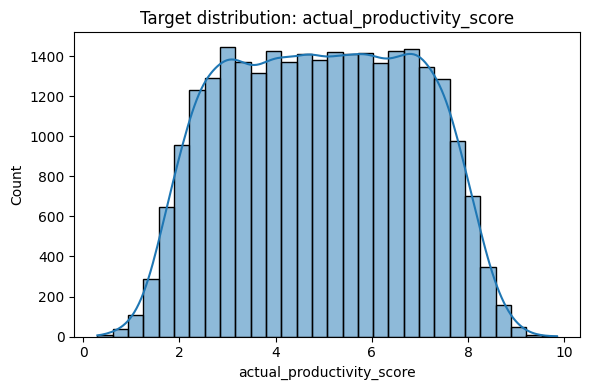

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET], bins=30, kde=True)
plt.title(f'Target distribution: {TARGET}')
plt.tight_layout()
plt.show()

In [11]:
## 2) EDA: summary statistics + visualizations

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,27635.0,41.479826,13.841794,18.000000,30.000000,41.000000,53.000000,65.000000
daily_social_media_time,25095.0,3.113776,2.076122,0.000000,1.633166,3.028026,4.375371,17.973256
number_of_notifications,27635.0,59.953790,7.726681,30.000000,55.000000,60.000000,65.000000,90.000000
work_hours_per_day,27635.0,6.989788,1.998848,0.000000,5.642869,6.988265,8.355012,12.000000
perceived_productivity_score,26150.0,5.506968,2.023710,2.000252,3.755549,5.522335,7.257807,8.999376
actual_productivity_score,27635.0,4.951805,1.883378,0.296812,3.373284,4.951742,6.526342,9.846258
stress_level,25880.0,5.521136,2.866118,1.000000,3.000000,6.000000,8.000000,10.000000
sleep_hours,25217.0,6.500628,1.460179,3.000000,5.496148,6.496858,7.500620,10.000000
screen_time_before_sleep,25593.0,1.026811,0.655147,0.000000,0.526840,1.007432,1.480793,3.000000
breaks_during_work,27635.0,4.988022,3.174607,0.000000,2.000000,5.000000,8.000000,10.000000


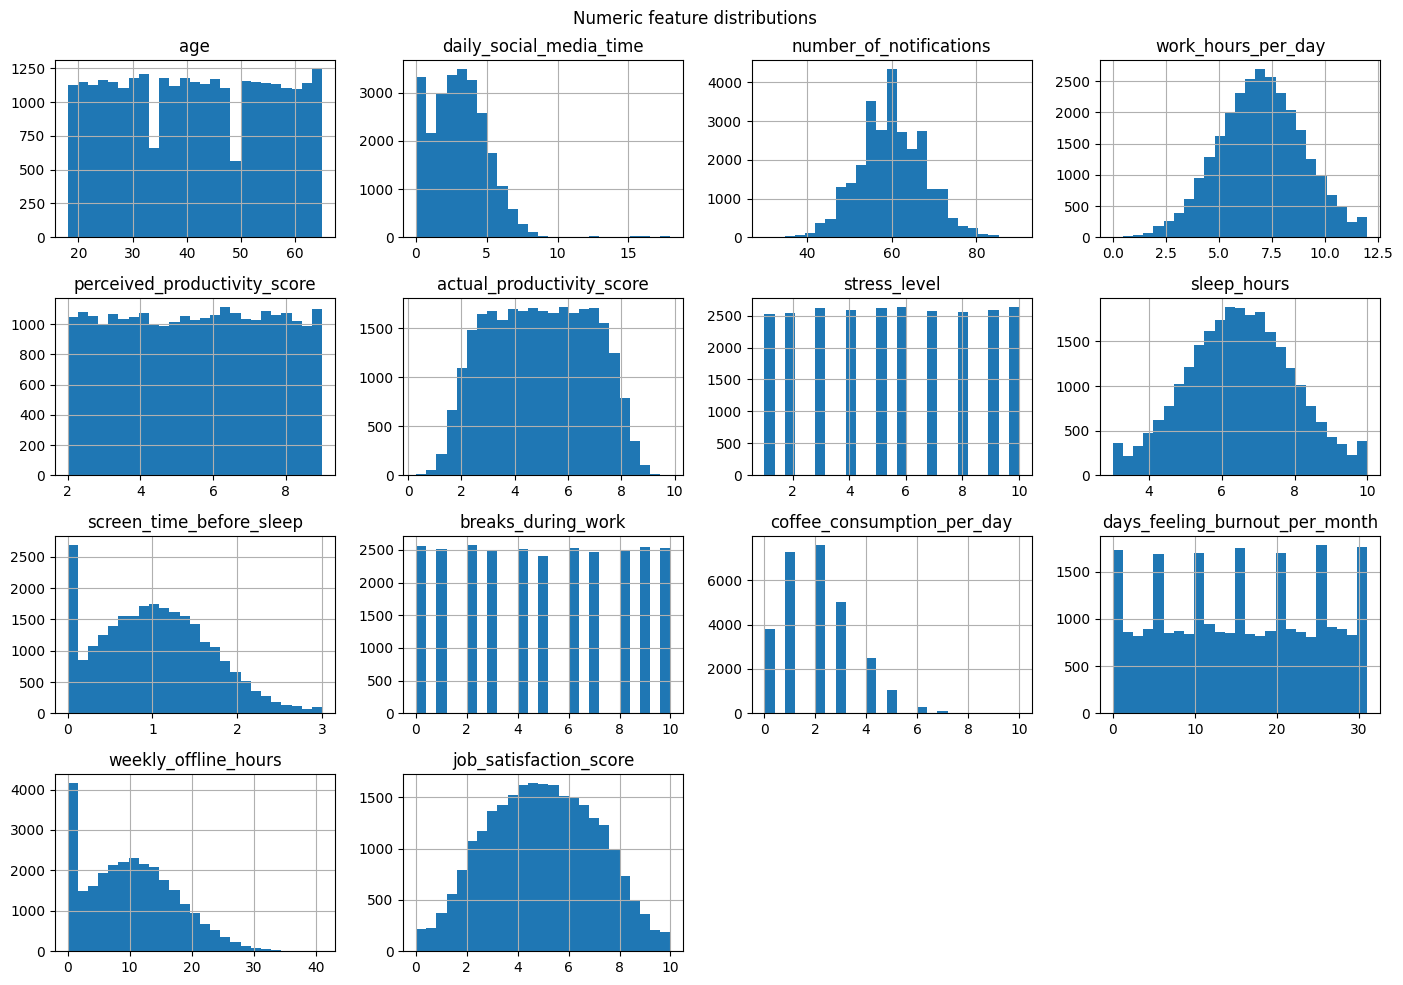

In [13]:
df[num_cols].hist(bins=25, figsize=(14,10))
plt.suptitle('Numeric feature distributions')
plt.tight_layout()
plt.show()

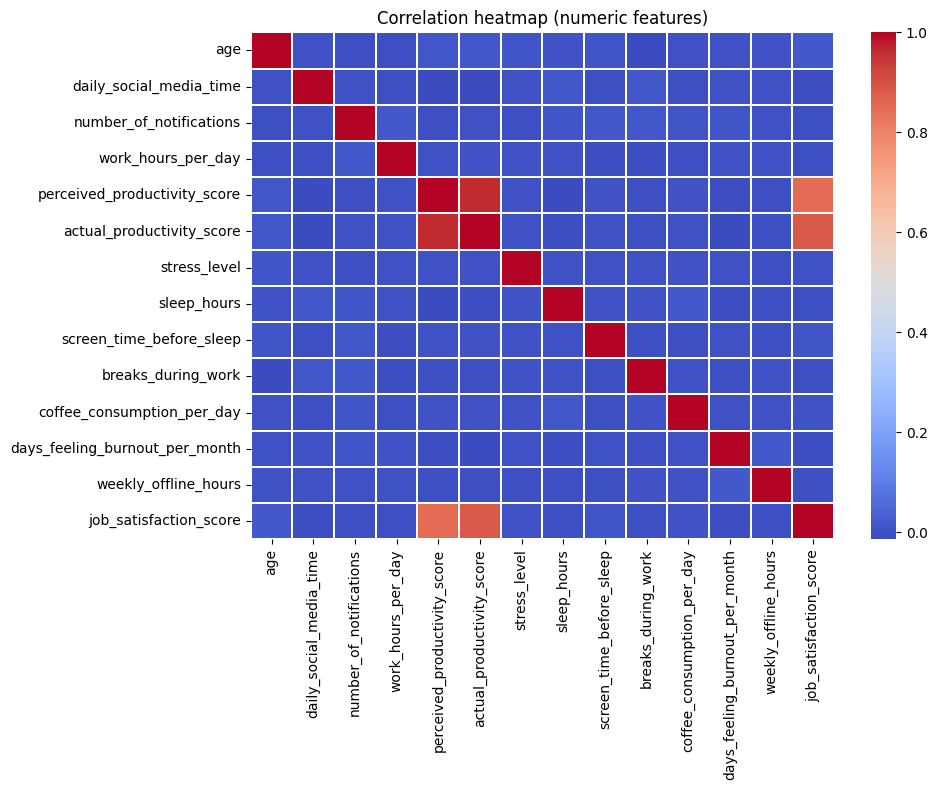

In [14]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', linewidths=0.2)
plt.title('Correlation heatmap (numeric features)')
plt.tight_layout()
plt.show()

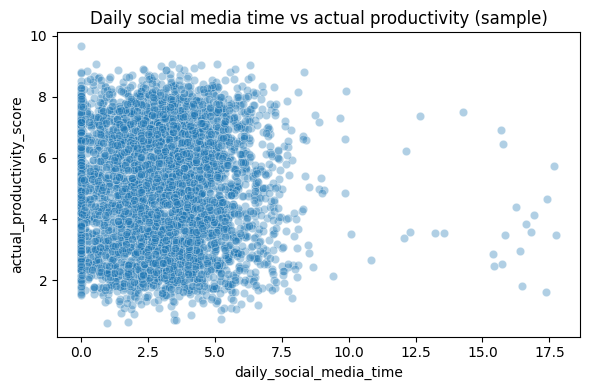

In [15]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='daily_social_media_time',
    y=TARGET,
    data=df.sample(5000, random_state=RANDOM_STATE),
    alpha=0.35,
)
plt.title('Daily social media time vs actual productivity (sample)')
plt.tight_layout()
plt.show()

In [16]:
## 3) Train/test split + preprocessing

In [17]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape

((22108, 18), (5527, 18))

In [18]:
# Explicit feature groups (more stable than inferring dtypes)
cat_cols = [c for c in [
    'gender',
    'job_type',
    'social_platform_preference',
    'uses_focus_apps',
    'has_digital_wellbeing_enabled',
] if c in X.columns]

num_cols = [c for c in X.columns if c not in cat_cols]

cat_cols, num_cols

(['gender',
  'job_type',
  'social_platform_preference',
  'uses_focus_apps',
  'has_digital_wellbeing_enabled'],
 ['age',
  'daily_social_media_time',
  'number_of_notifications',
  'work_hours_per_day',
  'perceived_productivity_score',
  'stress_level',
  'sleep_hours',
  'screen_time_before_sleep',
  'breaks_during_work',
  'coffee_consumption_per_day',
  'days_feeling_burnout_per_month',
  'weekly_offline_hours',
  'job_satisfaction_score'])

In [19]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocess = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
])

In [20]:
## 4) Task 3: Two classical regression models

In [21]:
def eval_reg(model, name):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)

    rmse_train = float(np.sqrt(mse_train))
    rmse_test = float(np.sqrt(mse_test))

    metrics = {
        'Model': name,
        'Train RMSE': rmse_train,
        'Test RMSE': rmse_test,
        'Test MAE': float(mean_absolute_error(y_test, pred_test)),
        'Test R2': float(r2_score(y_test, pred_test)),
    }
    print(name)
    print(metrics)
    return metrics

ridge = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])

rfr = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestRegressor(n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1)),
])

baseline = []
baseline.append(eval_reg(ridge, 'Ridge Regression'))
baseline.append(eval_reg(rfr, 'Random Forest Regressor'))
pd.DataFrame(baseline).sort_values('Test RMSE')

Ridge Regression
{'Model': 'Ridge Regression', 'Train RMSE': 0.569843640546118, 'Test RMSE': 0.5826749866635709, 'Test MAE': 0.42842488200509715, 'Test R2': 0.9057581542196081}
Random Forest Regressor
{'Model': 'Random Forest Regressor', 'Train RMSE': 0.1877281000903693, 'Test RMSE': 0.5205479477927916, 'Test MAE': 0.40107968934643895, 'Test R2': 0.9247836056254582}


,Model,Train RMSE,Test RMSE,Test MAE,Test R2
1,Random Forest Regressor,0.187728,0.520548,0.401080,0.924784
0,Ridge Regression,0.569844,0.582675,0.428425,0.905758


In [22]:
## 5) Task 2: Neural network regressor (MLPRegressor)

In [23]:
mlp = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=80,
        random_state=RANDOM_STATE,
    )),
])
baseline.append(eval_reg(mlp, 'Neural Net (MLPRegressor)'))
pd.DataFrame(baseline).sort_values('Test RMSE')


Neural Net (MLPRegressor)
{'Model': 'Neural Net (MLPRegressor)', 'Train RMSE': 0.4979085007647194, 'Test RMSE': 0.5666994867822683, 'Test MAE': 0.43016869885789255, 'Test R2': 0.9108550650716178}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (80) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Train RMSE,Test RMSE,Test MAE,Test R2
1,Random Forest Regressor,0.187728,0.520548,0.401080,0.924784
2,Neural Net (MLPRegressor),0.497909,0.566699,0.430169,0.910855
0,Ridge Regression,0.569844,0.582675,0.428425,0.905758


In [24]:
## 6) Task 4: Hyperparameter tuning with cross-validation

In [25]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

ridge_grid = {
    'model__alpha': [0.1, 1.0, 10.0, 50.0],
}
rfr_grid = {
    'model__n_estimators': [300, 600],
    'model__max_depth': [None, 8, 16],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2],
}

ridge_search = GridSearchCV(ridge, ridge_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
rfr_search = GridSearchCV(rfr, rfr_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)

ridge_search.fit(X_train, y_train)
rfr_search.fit(X_train, y_train)

ridge_search.best_params_, -ridge_search.best_score_, rfr_search.best_params_, -rfr_search.best_score_


KeyboardInterrupt: 

In [ ]:
## 7) Task 5: Feature selection

In [ ]:
selector = SelectKBest(score_func=f_regression, k=10)

ridge_final = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', selector),
    ('model', Ridge(alpha=ridge_search.best_params_['model__alpha'], random_state=RANDOM_STATE)),
])

rfr_final = Pipeline(steps=[
    ('preprocess', preprocess),
    ('select', selector),
    ('model', RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        n_estimators=rfr_search.best_params_['model__n_estimators'],
        max_depth=rfr_search.best_params_['model__max_depth'],
        min_samples_split=rfr_search.best_params_['model__min_samples_split'],
        min_samples_leaf=rfr_search.best_params_['model__min_samples_leaf'],
    )),
])

final_rows = []
final_rows.append(eval_reg(ridge_final, 'Ridge (tuned + FS)'))
final_rows.append(eval_reg(rfr_final, 'RF Regressor (tuned + FS)'))
final_rows


In [ ]:
## 8) Task 6: Final comparative table (Table 2 format)

In [ ]:
table2 = pd.DataFrame(final_rows)
table2.insert(1, 'Features Used', ['Selected (k=10)', 'Selected (k=10)'])
table2.insert(2, 'CV Score (RMSE)', [-ridge_search.best_score_, -rfr_search.best_score_])
table2 = table2[[
    'Model', 'Features Used', 'CV Score (RMSE)', 'Test RMSE', 'Test R2'
]]
table2


In [ ]:
table2.to_csv(os.path.join(OUT_DIR, 'Table2_Final_Regression_Models.csv'), index=False)
os.path.join(OUT_DIR, 'Table2_Final_Regression_Models.csv')


In [ ]:
## 9) Conclusion & Reflection (draft)\n
- **Model performance:** compare RMSE and R2 on test set; lower RMSE and higher R2 is better.\n
- **Impact of methods:** CV tuning stabilizes model selection; FS can reduce overfitting and simplify models.\n
- **Future directions:** try GradientBoosting/XGBoost, feature engineering, and early stopping for the NN.